# Layer 2: Semantic Analysis

This layer analyzes semantic content for fake news detection.

In [ ]:
# Layer 2 Semantic Analysis Implementation

In [8]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")
print("SentenceTransformer ready")

c:\Users\HarshilA\miniconda3\envs\aiml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful
SentenceTransformer ready


In [ ]:
# Cell 2 — Load Dataset
import pandas as pd
df = pd.read_csv('../global_train.csv')
# In our global splits, FAKE is 1 and REAL is 0 (to align with Layer 1)
df['label'] = df['label'].apply(lambda x: 0 if x == 1 else 1) # Layer 2 logic originally had FAKE=0, REAL=1
print(f"Total training articles: {len(df)}")


Fake articles: 23481
Real articles: 21417
Total: 44898

Columns: ['title', 'text', 'subject', 'date', 'label']

First article preview:
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger a


In [5]:
# Cell 3 — Basic EDA
print("=== Dataset Info ===")
print(df.info())

print("\n=== Null Values ===")
print(df.isnull().sum())

print("\n=== Class Distribution ===")
print(df['label'].value_counts())
print(f"\nFake %: {df[df['label']==0].shape[0]/len(df)*100:.1f}%")
print(f"Real %: {df[df['label']==1].shape[0]/len(df)*100:.1f}%")

print("\n=== Subject Categories ===")
print(df['subject'].value_counts())

# Article length analysis
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
print("\n=== Article Length Stats ===")
print(df.groupby('label')['text_length'].describe())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 1.7 MB
None

=== Null Values ===
title      0
text       0
subject    0
date       0
label      0
dtype: int64

=== Class Distribution ===
label
0    23481
1    21417
Name: count, dtype: int64

Fake %: 52.3%
Real %: 47.7%

=== Subject Categories ===
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

=== Article Length Stats ===
         count        mean         std  min    25%    50%    75%     max
labe

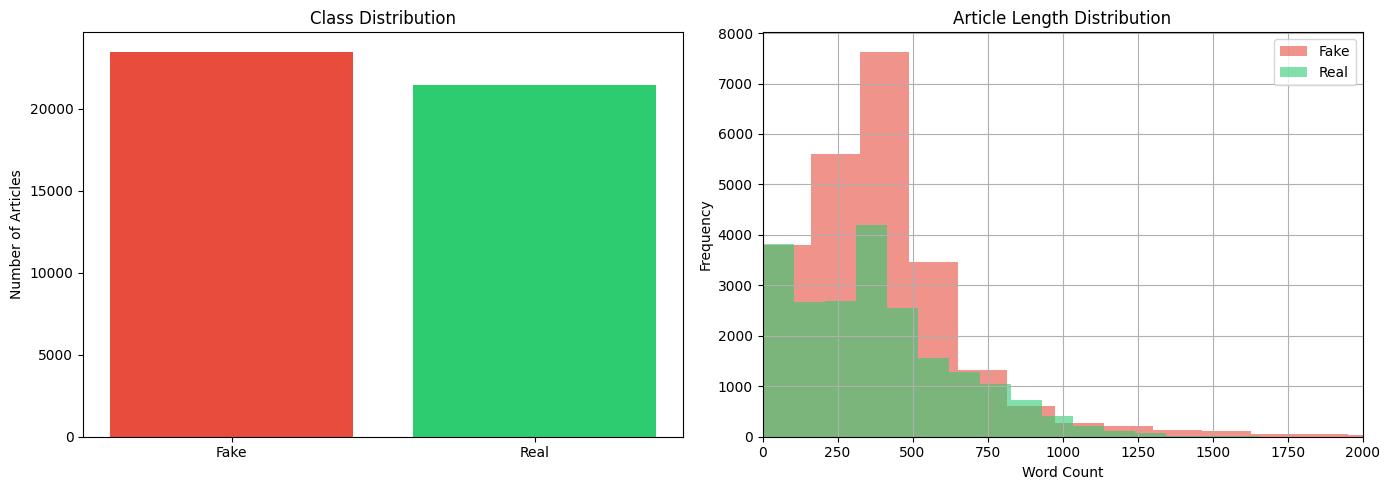

In [9]:
# Cell 4 — Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Class distribution
axes[0].bar(['Fake', 'Real'], 
            [df[df['label']==0].shape[0], df[df['label']==1].shape[0]],
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Articles')

# Plot 2 — Article length distribution
df[df['label']==0]['text_length'].hist(bins=50, alpha=0.6, 
                                        color='#e74c3c', 
                                        label='Fake', ax=axes[1])
df[df['label']==1]['text_length'].hist(bins=50, alpha=0.6, 
                                        color='#2ecc71', 
                                        label='Real', ax=axes[1])
axes[1].set_title('Article Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.show()

In [10]:
# Cell 5 — Prepare data
df['combined'] = df['title'] + ' ' + df['text']
train_df = df[df['combined'].str.strip() != ''].copy()

test_df = pd.read_csv('../global_test.csv')
test_df['label'] = test_df['label'].apply(lambda x: 0 if x == 1 else 1)
test_df['combined'] = test_df['title'] + ' ' + test_df['text']
test_df = test_df[test_df['combined'].str.strip() != ''].copy()

print(f"Training set: {len(train_df)} articles")
print(f"Test set: {len(test_df)} articles")


Training set: 35918 articles
Test set: 8980 articles

Train label distribution:
label
0    18785
1    17133
Name: count, dtype: int64

Test label distribution:
label
0    4696
1    4284
Name: count, dtype: int64


In [11]:
# Cell 6 — Generate Embeddings
# Load pretrained model
print("Loading sentence transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded!")

# Take a subset for speed — 5000 train, 1000 test
# Full dataset would take too long on CPU
train_sample = train_df.sample(n=5000, random_state=42)
test_sample = test_df.sample(n=1000, random_state=42)

print(f"\nGenerating training embeddings ({len(train_sample)} articles)...")
train_embeddings = model.encode(
    train_sample['combined'].tolist(),
    batch_size=32,
    show_progress_bar=True
)

print(f"\nGenerating test embeddings ({len(test_sample)} articles)...")
test_embeddings = model.encode(
    test_sample['combined'].tolist(),
    batch_size=32,
    show_progress_bar=True
)

print(f"\nTraining embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Loading sentence transformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2902.93it/s]


Model loaded!

Generating training embeddings (5000 articles)...


Batches: 100%|██████████| 157/157 [03:17<00:00,  1.26s/it]



Generating test embeddings (1000 articles)...


Batches: 100%|██████████| 32/32 [00:19<00:00,  1.62it/s]


Training embeddings shape: (5000, 384)
Test embeddings shape: (1000, 384)


In [12]:
# Cell 7 — Semantic Similarity Classification

# Separate training embeddings by label
train_labels = train_sample['label'].values
fake_embeddings = train_embeddings[train_labels == 0]  # all fake article vectors
real_embeddings = train_embeddings[train_labels == 1]  # all real article vectors

# Build "knowledge base" — average embedding per class
# This gives us one representative vector for fake and one for real
fake_centroid = np.mean(fake_embeddings, axis=0, keepdims=True)
real_centroid = np.mean(real_embeddings, axis=0, keepdims=True)

print(f"Fake centroid shape: {fake_centroid.shape}")
print(f"Real centroid shape: {real_centroid.shape}")
print(f"Fake training articles: {fake_embeddings.shape[0]}")
print(f"Real training articles: {real_embeddings.shape[0]}")

# For each test article — measure similarity to both centroids
fake_similarities = cosine_similarity(test_embeddings, fake_centroid).flatten()
real_similarities = cosine_similarity(test_embeddings, real_centroid).flatten()

print(f"\nSample similarities for first test article:")
print(f"  Similarity to fake centroid: {fake_similarities[0]:.4f}")
print(f"  Similarity to real centroid: {real_similarities[0]:.4f}")

# Predict — whichever centroid is closer wins
predictions = (real_similarities > fake_similarities).astype(int)

print(f"\nSample prediction for first article: {'REAL' if predictions[0]==1 else 'FAKE'}")
print(f"Actual label: {'REAL' if test_sample['label'].values[0]==1 else 'FAKE'}")

Fake centroid shape: (1, 384)
Real centroid shape: (1, 384)
Fake training articles: 2630
Real training articles: 2370

Sample similarities for first test article:
  Similarity to fake centroid: 0.5909
  Similarity to real centroid: 0.4863

Sample prediction for first article: FAKE
Actual label: FAKE


=== Classification Report ===
              precision    recall  f1-score   support

        Fake       0.87      0.88      0.88       507
        Real       0.88      0.86      0.87       493

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



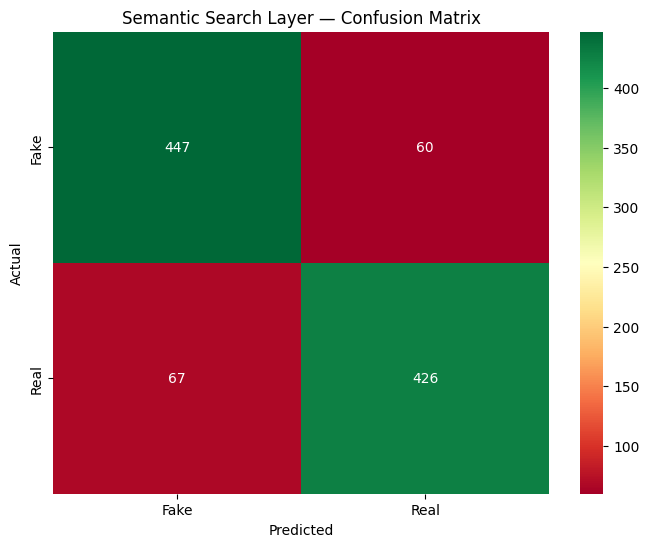


Overall Accuracy: 87.30%


In [13]:
# Cell 8 — Full Evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_labels = test_sample['label'].values

# Classification report
print("=== Classification Report ===")
print(classification_report(test_labels, predictions, 
                           target_names=['Fake', 'Real']))

# Confusion matrix
cm = confusion_matrix(test_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Semantic Search Layer — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Summary
accuracy = (predictions == test_labels).mean()
print(f"\nOverall Accuracy: {accuracy*100:.2f}%")

In [14]:
# Cell 9 — Classifiers on Embeddings
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import time

train_labels = train_sample['label'].values
test_labels = test_sample['label'].values

results = {}

# --- Logistic Regression ---
print("Training Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(train_embeddings, train_labels)
lr_preds = lr.predict(test_embeddings)
lr_time = time.time() - start
results['Logistic Regression'] = {
    'accuracy': (lr_preds == test_labels).mean(),
    'f1': f1_score(test_labels, lr_preds, average='weighted'),
    'time': lr_time
}
print(f"Done in {lr_time:.1f}s — Accuracy: {results['Logistic Regression']['accuracy']*100:.2f}%")

# --- SVM ---
print("\nTraining SVM...")
start = time.time()
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(train_embeddings, train_labels)
svm_preds = svm.predict(test_embeddings)
svm_time = time.time() - start
results['SVM'] = {
    'accuracy': (svm_preds == test_labels).mean(),
    'f1': f1_score(test_labels, svm_preds, average='weighted'),
    'time': svm_time
}
print(f"Done in {svm_time:.1f}s — Accuracy: {results['SVM']['accuracy']*100:.2f}%")

# --- XGBoost ---
print("\nTraining XGBoost...")
start = time.time()
xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     eval_metric='logloss', verbosity=0)
xgb.fit(train_embeddings, train_labels)
xgb_preds = xgb.predict(test_embeddings)
xgb_time = time.time() - start
results['XGBoost'] = {
    'accuracy': (xgb_preds == test_labels).mean(),
    'f1': f1_score(test_labels, xgb_preds, average='weighted'),
    'time': xgb_time
}
print(f"Done in {xgb_time:.1f}s — Accuracy: {results['XGBoost']['accuracy']*100:.2f}%")

# --- Comparison Table ---
print("\n=== Model Comparison ===")
print(f"{'Model':<22} {'Accuracy':>10} {'F1 Score':>10} {'Time':>8}")
print("-" * 55)
for name, r in results.items():
    print(f"{name:<22} {r['accuracy']*100:>9.2f}% {r['f1']:>10.4f} {r['time']:>6.1f}s")

Training Logistic Regression...
Done in 0.1s — Accuracy: 93.40%

Training SVM...
Done in 33.9s — Accuracy: 95.60%

Training XGBoost...
Done in 12.3s — Accuracy: 93.90%

=== Model Comparison ===
Model                    Accuracy   F1 Score     Time
-------------------------------------------------------
Logistic Regression        93.40%     0.9340    0.1s
SVM                        95.60%     0.9560   33.9s
XGBoost                    93.90%     0.9390   12.3s


=== Layer 2 Final Results ===
Centroid Baseline:    87.30%
Logistic Regression:  93.40%
XGBoost:              93.90%
SVM:                  95.60%
Ensemble (weighted):  96.00%  ← Layer 2 final
Ensemble F1:          0.9600


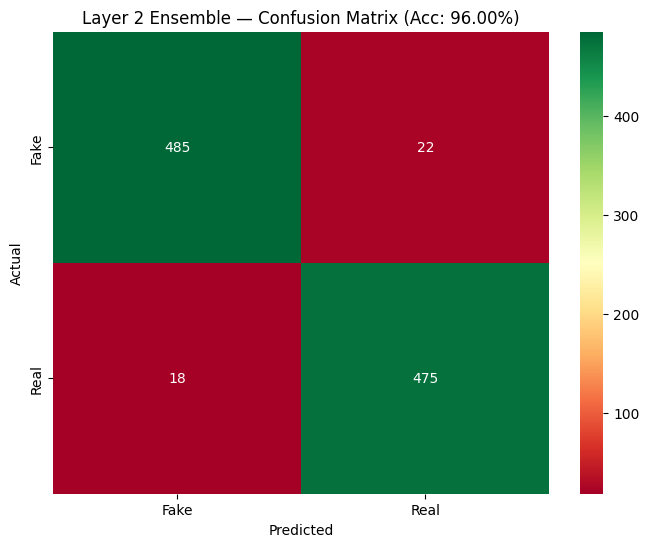

In [15]:
# Cell 10 — Ensemble + Final Evaluation

# Get probability scores from each model
lr_probs = lr.predict_proba(test_embeddings)[:, 1]   # probability of REAL
svm_probs = svm.predict_proba(test_embeddings)[:, 1]
xgb_probs = xgb.predict_proba(test_embeddings)[:, 1]

# Weighted ensemble — SVM gets highest weight since it performed best
ensemble_probs = (0.2 * lr_probs + 
                  0.5 * svm_probs + 
                  0.3 * xgb_probs)

ensemble_preds = (ensemble_probs > 0.5).astype(int)

ensemble_acc = (ensemble_preds == test_labels).mean()
ensemble_f1 = f1_score(test_labels, ensemble_preds, average='weighted')

print(f"=== Layer 2 Final Results ===")
print(f"Centroid Baseline:    87.30%")
print(f"Logistic Regression:  93.40%")
print(f"XGBoost:              93.90%")
print(f"SVM:                  95.60%")
print(f"Ensemble (weighted):  {ensemble_acc*100:.2f}%  ← Layer 2 final")
print(f"Ensemble F1:          {ensemble_f1:.4f}")

# Confusion matrix for final ensemble
cm = confusion_matrix(test_labels, ensemble_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title(f'Layer 2 Ensemble — Confusion Matrix (Acc: {ensemble_acc*100:.2f}%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# Cell 11 — Final Layer 2 Function (handoff to ensemble)

def layer2_predict(article_text):
    """
    Layer 2: Semantic Search
    Input:  raw article string
    Output: dict with label, confidence, reason
    """
    # Generate embedding for input article
    embedding = model.encode([article_text])
     
    # Get probability from each classifier
    lr_prob = lr.predict_proba(embedding)[0][1]
    svm_prob = svm.predict_proba(embedding)[0][1]
    xgb_prob = xgb.predict_proba(embedding)[0][1]
    
    # Weighted ensemble
    final_prob = 0.2*lr_prob + 0.5*svm_prob + 0.3*xgb_prob
    
    label = "REAL" if final_prob > 0.5 else "FAKE"
    confidence = final_prob if final_prob > 0.5 else 1 - final_prob
    
    reason = (f"Semantically similar to known "
              f"{'real' if label=='REAL' else 'fake'} articles "
              f"(SVM-led ensemble, {confidence*100:.1f}% confident)")
    
    return {
        "label": label,
        "confidence": round(confidence, 4),
        "reason": reason
    }

# Test it
test_article = "Scientists confirm vaccines are safe and effective"
result = layer2_predict(test_article)
print(f"Article: {test_article}")
print(f"Result: {result}")

test_article2 = "SHOCKING: Government hiding truth about secret mind control"
result2 = layer2_predict(test_article2)
print(f"\nArticle: {test_article2}")
print(f"Result: {result2}")

Article: Scientists confirm vaccines are safe and effective
Result: {'label': 'REAL', 'confidence': np.float64(0.812), 'reason': 'Semantically similar to known real articles (SVM-led ensemble, 81.2% confident)'}

Article: SHOCKING: Government hiding truth about secret mind control
Result: {'label': 'FAKE', 'confidence': np.float64(0.9906), 'reason': 'Semantically similar to known fake articles (SVM-led ensemble, 99.1% confident)'}


In [17]:
# Cell 12 — Verify handoff is clean
test_cases = [
    "Breaking: Scientists discover cure for cancer after decades of research",
    "EXPOSED: Deep state plot to destroy America revealed by insider",
    "Federal Reserve raises interest rates by 0.25 percent amid inflation concerns",
    "SHOCKING truth about chemtrails they don't want you to know"
]

print("=== Layer 2 Final Verification ===\n")
for article in test_cases:
    result = layer2_predict(article)
    print(f"Text: {article[:60]}...")
    print(f"→ {result['label']} ({result['confidence']*100:.1f}%) | {result['reason']}")
    print()

=== Layer 2 Final Verification ===

Text: Breaking: Scientists discover cure for cancer after decades ...
→ FAKE (72.8%) | Semantically similar to known fake articles (SVM-led ensemble, 72.8% confident)

Text: EXPOSED: Deep state plot to destroy America revealed by insi...
→ FAKE (99.3%) | Semantically similar to known fake articles (SVM-led ensemble, 99.3% confident)

Text: Federal Reserve raises interest rates by 0.25 percent amid i...
→ REAL (90.6%) | Semantically similar to known real articles (SVM-led ensemble, 90.6% confident)

Text: SHOCKING truth about chemtrails they don't want you to know...
→ FAKE (95.4%) | Semantically similar to known fake articles (SVM-led ensemble, 95.4% confident)



In [18]:
# Cell 13 — Save everything to disk
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Save all three classifiers
with open('../models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print("✓ Models saved to /models folder")

# Loading them back would be:
# with open('../models/svm_model.pkl', 'rb') as f:
#     svm = pickle.load(f)

✓ Models saved to /models folder
